In [37]:
import yfinance as yf
import pandas as pd

df = yf.download("GOOGL", start="2018-01-01", end="2026-01-01", progress=False)
df = df.reset_index()
first_price_col = df.columns[1]  # depois do Date
df.loc[0, first_price_col] = df.loc[2, first_price_col]
df = df.drop(index=1).reset_index(drop=True)
df.to_csv()
df.iloc[1:].head()
df = df.set_index("Date")
df.columns = df.columns.get_level_values(0)

print(df)

Price            Close        High         Low        Open    Volume
Date                                                                
2018-01-02   54.338882   53.357999   52.219411   52.219411  31766000
2018-01-04   54.338882   54.751473   54.264500   54.404839  26052000
2018-01-05   55.059437   55.222590   54.638417   54.720241  30250000
2018-01-08   55.253826   55.499299   55.045053   55.094642  24644000
2018-01-09   55.183411   55.463596   54.955792   55.463596  26808000
...                ...         ...         ...         ...       ...
2025-12-24  313.869049  314.858343  311.700593  314.548563  10097400
2025-12-26  313.289459  314.868334  312.060314  314.258778  10899000
2025-12-29  313.339417  313.799084  310.401482  311.150955  19621800
2025-12-30  313.629242  316.727067  312.240205  312.280185  17380900
2025-12-31  312.779816  314.358691  311.220916  312.629927  16377700

[2010 rows x 5 columns]


In [38]:
df.iloc[1:].head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-04,54.338882,54.751473,54.264500,54.404839,26052000
2018-01-05,55.059437,55.222590,54.638417,54.720241,30250000
2018-01-08,55.253826,55.499299,55.045053,55.094642,24644000
2018-01-09,55.183411,55.463596,54.955792,55.463596,26808000
2018-01-10,55.051994,55.182912,54.746520,54.896280,20734000


In [39]:
print(df.columns)
print(type(df["Close"]))

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
<class 'pandas.Series'>


In [40]:
import ta

def build_features(df):
    df = df.copy()

    df["Close "] = pd.to_numeric(df["Close"], errors="coerce")

    df = df.dropna()

    # returns
    df["return"] = df["Close"].pct_change()

    # RSI
    df["RSI"] = ta.momentum.RSIIndicator(df["Close"], window=14).rsi()

    # MACD
    macd = ta.trend.MACD(df["Close"])
    df["MACD"] = macd.macd()
    df["MACD_SIGNAL"] = macd.macd_signal()
    df["MACD_HIST"] = macd.macd_diff()

    # volatilidade
    df["STD_14"] = df["Close"].rolling(14).std()

    # Bollinger
    ma20 = df["Close"].rolling(20).mean()
    std20 = df["Close"].rolling(20).std()

    df["BB_upper"] = ma20 + 2 * std20
    df["BB_lower"] = ma20 - 2 * std20

    # targets (ML)
    df["target_price"] = df["Close"].shift(-1)
    df["target_dir"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

    return df.dropna()

In [41]:
df = build_features(df)

In [42]:
def time_split(X, y, ratio=0.8):
    split = int(len(X) * ratio)

    return (
        X.iloc[:split],
        X.iloc[split:],
        y.iloc[:split],
        y.iloc[split:]
    )

In [43]:
features = [
    "Open", "High", "Low", "Close",
    "RSI", "MACD", "MACD_SIGNAL", "MACD_HIST",
    "STD_14", "return"
]

X = df[features]
y_price = df["target_price"]
y_dir = df["target_dir"]
X_train, X_test, y_price_train, y_price_test = time_split(X, y_price)
_, _, y_dir_train, y_dir_test = time_split(X, y_dir)

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

model_price = RandomForestRegressor(n_estimators=200, random_state=42)
model_price.fit(X_train, y_price_train)

preds = model_price.predict(X_test)
MAE= mean_absolute_error(y_price_test, preds)
mae_percent = MAE / y_price_test.mean() * 100
print(mae_percent)
print("MAE:", MAE)

15.426293611215632
MAE: 30.220485830210674


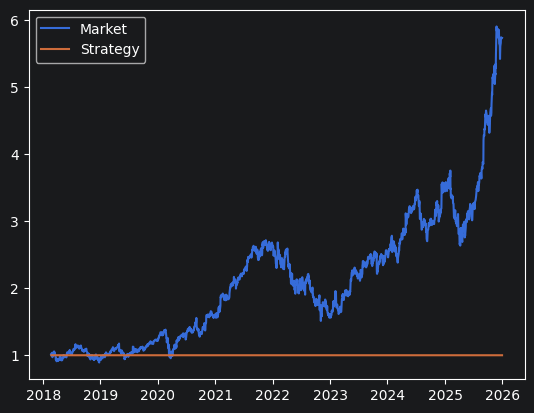

In [46]:
import matplotlib.pyplot as plt

df["strategy"] = (model_price.predict(X) == 1).astype(int)
df["strategy_return"] = df["strategy"].shift(1) * df["return"]
df["cumulative_market"] = (1 + df["return"]).cumprod()
df["cumulative_strategy"] = (1 + df["strategy_return"]).cumprod()

plt.plot(df["cumulative_market"], label="Market")
plt.plot(df["cumulative_strategy"], label="Strategy")
plt.legend()
plt.show()

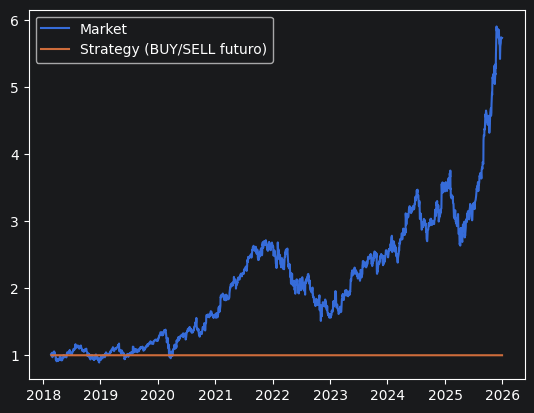

In [48]:
import matplotlib.pyplot as plt

plt.plot(df["cumulative_market"], label="Market")
plt.plot(df["cumulative_strategy"], label="Strategy (BUY/SELL futuro)")
plt.legend()
plt.show()